This notebook is to be used for the dataset from kaggle creditcard.csv . Several models are used, such as logistic regression/ RandomForest thus XGBoost


Q 1.1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix


In [ ]:
Q1-4

    Time        V1        V2        V3        V4        V5        V6  \
0    0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1    0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2    1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3    1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4    2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
..   ...       ...       ...       ...       ...       ...       ...   
95  64.0 -0.658305  0.406791  2.037461 -0.291298  0.147910 -0.350857   
96  64.0  0.959602  0.370711  0.888613  2.343244  0.352491  1.365515   
97  67.0 -0.653445  0.160225  1.592256  1.296832  0.997175 -0.343000   
98  67.0 -1.494668  0.837241  2.628211  3.145414 -0.609098  0.258495   
99  68.0  1.232996  0.189454  0.491040  0.633673 -0.511574 -0.990609   

          V7        V8        V9  ...       V21       V22       V23       V24  \
0   0.239599  0.098698  0.363787  ... -0.018307  0.277

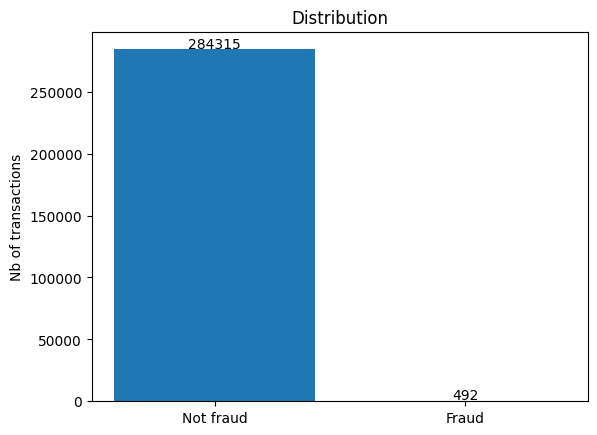

In [4]:
data = pd.read_csv("creditcard.csv")

#data.info()
#data.describe()
print(data.head(100))
test = data.groupby("Class").size()
print(test)
#select the number of one
one = data[data["Class"] == 1]
print(data.shape)

pl = data['Class'].value_counts()

plt.bar(['Not fraud', 'Fraud'], pl.values)
plt.title("Distribution")
plt.ylabel("Nb of transactions")

for i,v in enumerate(pl.values):
    plt.text(i,v + 1000, str(v), ha="center")
plt.show()

X = data.drop("Class",axis=1)
y = data["Class"]

X_train,X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Comments: Here as we may see, there is no normal distribution, and a tremendous gap between the number of frauds and those who are not FRAUDS which undoubtedly means frauds are seldomly commited

PART 2

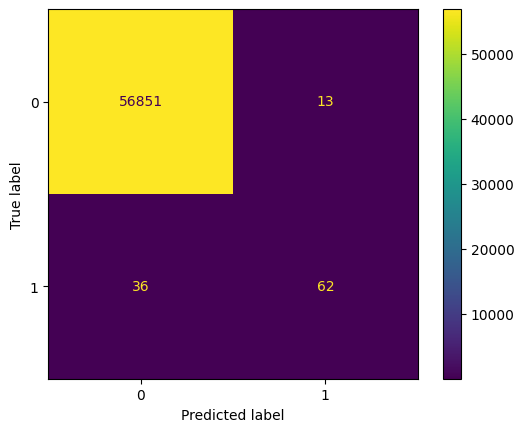

Accuracy0.9991397773954567

Precision0.8266666666666667

Recall0.8266666666666667

F1 score 0.7167630057803468

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
model = LogisticRegression()
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test,y_pred)
matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
matrix.plot()
plt.show()

print(f"Accuracy{accuracy_score(y_test,y_pred)}\n")
print(f"Precision{precision_score(y_test,y_pred)}\n")
print(f"Recall{precision_score(y_test,y_pred)}\n")
print(f"F1 score {f1_score(y_test,y_pred)}\n")

print(classification_report(y_test,y_pred))

Here what information may be observed and retrieved ? 

Confusion Matrix:
56 851 of TN, Normal frauds, perfect
62 TP, classified as frauds
36 FP, a few errors (missed frauds)
13 FN, a few erros on normal transactions

Metrics:

Accuracy way too high, but that's because we are using an unbalanced set
Precision: around 82% detected 
Recall: 62% are real frauds

PART 3

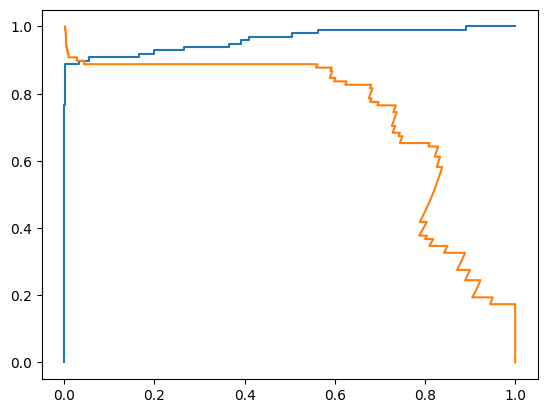

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
y_scores = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")

#precision and recall slope
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)
plt.plot(precision, recall, label=f"AP = {ap:.4f}")


Our graphic shows 2 things, the ROC curve and Precision Curbe

ROC CURVE: shows a good model AUC almost to 1 !
However
Regarding the precision curve, it always declines as it is to be expected, the recall increases when the precision declines as it tries to detect more frauds

PART 4.1

In [8]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
print("RandomForest \n")

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, pred_rf):.4f}")
print(f"F1 score: {f1_score(y_test, pred_rf):.4f}")


RandomForest 

Accuracy: 0.9993
Precision: 0.7941
Recall: 0.8265
F1 score: 0.8100


Good results, as to be expected of a randomforest algorithm as it is more inclined to use bagging and boostrap for the data, therefore less inclined to overfitting/underfitting

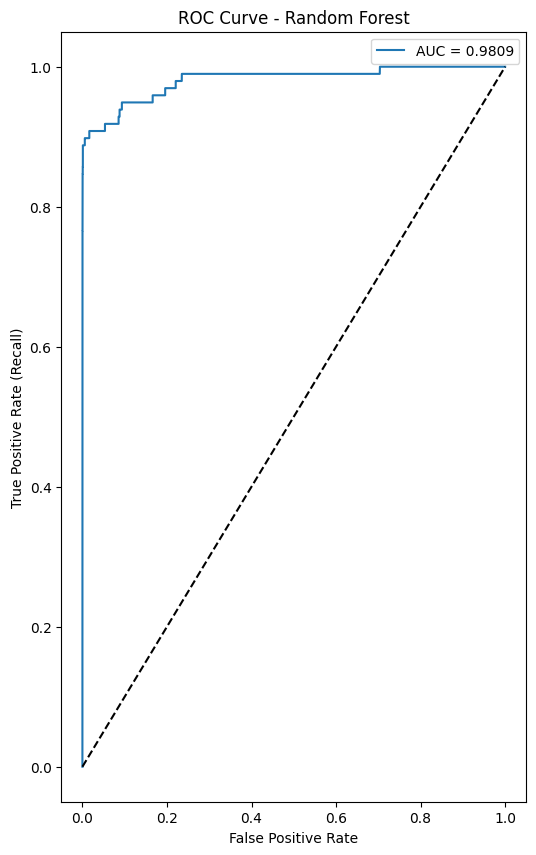

In [9]:
scores_rf = rf.predict_proba(X_test_scaled)[:, 1]

# ROC Curve Random Forest
fpr, tpr, thresholds = roc_curve(y_test, scores_rf)
auc = roc_auc_score(y_test, scores_rf)
plt.figure(figsize=(6, 10))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Random Forest")
plt.legend()



The graph shows us a good AUC almost 1

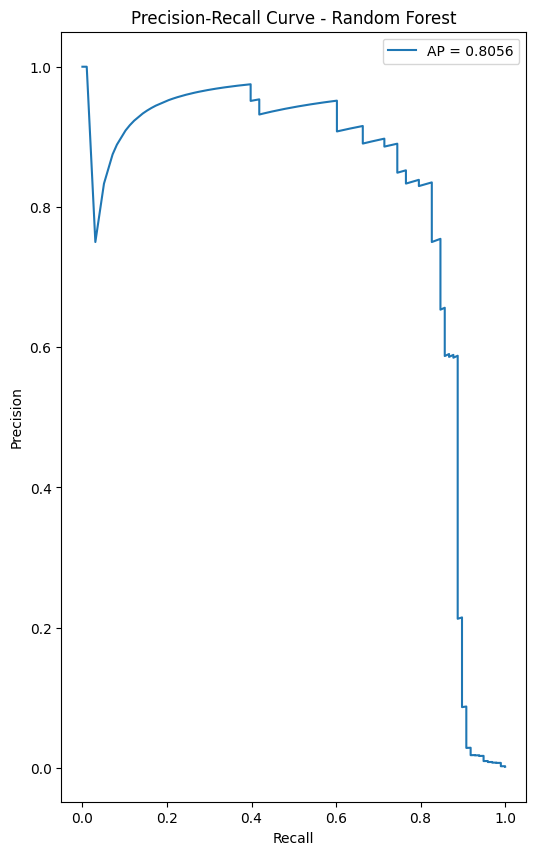

In [10]:
# Precision-Recall Curve Random Forest
precision, recall, thresholds = precision_recall_curve(y_test, scores_rf)
ap = average_precision_score(y_test, scores_rf)

plt.figure(figsize=(6, 10))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.show()


Our AP shows that, as the recall increases the precision declines which is normal

In this section I do use XGBoost: HOWEVER, due to the means I have available my machine cannot support it
So only the code has been writen

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

print("Now let us use the GradientBoosting classifier\n")

gb = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=13,
    subsample=1.0,
    random_state=42
)

gb.fit(X_train_scaled, y_train)
pred_gb = gb.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, pred_gb):.4f}")
print(f"Precision : {precision_score(y_test, pred_gb):.4f}")
print(f"Recall : {recall_score(y_test, pred_gb):.4f}")
print(f"F1-score : {f1_score(y_test, pred_gb):.4f}")

print(classification_report(y_test, pred_gb))
y_scores_gb = gb.predict_proba(X_test_scaled)[:, 1]

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_scores_gb)
auc_gb = roc_auc_score(y_test, y_scores_gb)

plt.figure(figsize=(6,6))
plt.plot(fpr_gb, tpr_gb, label=f"AUC = {auc_gb:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

# Precision-Recall
prec_gb, rec_gb, _ = precision_recall_curve(y_test, y_scores_gb)
ap_gb = average_precision_score(y_test, y_scores_gb)

plt.figure(figsize=(6,6))
plt.plot(rec_gb, prec_gb, label=f"AP = {ap_gb:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting")
plt.legend()
plt.show()


CROSS VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score

print("RandomForest with Cross Validation\n")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print(f"Scores per fold: {scores}")
print(f"Mean AUC: {scores.mean():.4f}")
print(f"Standard deviation: {scores.std():.4f}")

RandomForest with Cross Validation



I had to retrieve the results from my vscode previously compiled code as I ran into issues

Scores per fold : [0.96052502 0.98704626 0.98688347 0.96256501 0.99292876]
Mean AUC : 0.9780
Standard-Deviation : 0.0136

AUC is really good, that means a good separability of our data
and a meager Standard-Deviation, which means a run doesn't vary from another(one fold to another)
We do have a good model here

END OF TP


